# NIH Chest X-ray - Improved Multi-label Classification + Grad-CAM Localization

This notebook improves your previous version with:

- better image size (`384`)
- weighted `BCEWithLogitsLoss`
- stronger fine-tuning (`denseblock3` + `denseblock4`)
- learning-rate scheduler
- early stopping
- mixed precision training
- per-class AUC
- best threshold search for each class
- Grad-CAM + bounding box visualization

In [55]:
# Cell 1: Imports
import os
import glob
import cv2
import copy
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")

In [56]:
# Cell 2: Seed and device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cpu


In [57]:
# Cell 3: Dataset path
# Update this path for your Colab / Kaggle / local machine
base_dir = "/Users/ahsanurrahman/Antigravity/NIH/small_nih_dataset"   # <-- change if needed

data_csv = os.path.join(base_dir, "Data_Entry_2017.csv")
bbox_csv = os.path.join(base_dir, "BBox_List_2017.csv")

print("Base dir exists:", os.path.exists(base_dir))
print("Data CSV exists :", os.path.exists(data_csv))
print("BBox CSV exists :", os.path.exists(bbox_csv))

Base dir exists: True
Data CSV exists : True
BBox CSV exists : True


In [58]:
# Cell 4: Load metadata
df = pd.read_csv(data_csv)
bbox_df = pd.read_csv(bbox_csv)

print("df shape     :", df.shape)
print("bbox_df shape:", bbox_df.shape)
display(df.head())
display(bbox_df.head())

df shape     : (1000, 12)
bbox_df shape: (11, 9)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00022260_003.png,No Finding,3,22260,54,F,PA,2542,2434,0.143,0.143,NaN
1,00012048_007.png,Infiltration|Mass|Nodule,7,12048,65,M,AP,2500,2048,0.168,0.168,NaN
2,00014352_005.png,No Finding,5,14352,6,M,PA,2992,2033,0.143,0.143,NaN
3,00006040_001.png,No Finding,1,6040,18,F,AP,2500,2048,0.171,0.171,NaN
4,00011202_002.png,No Finding,2,11202,19,M,AP,2500,2048,0.168,0.168,NaN


,Image Index,Finding Label,Bbox [x,y,w,h],Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00000211_010.png,Atelectasis,353.084746,535.087013,101.966102,168.135593,NaN,NaN,NaN
1,00015770_010.png,Cardiomegaly,363.932203,470.002268,451.254237,271.186441,NaN,NaN,NaN
2,00029808_003.png,Cardiomegaly,321.627119,410.341251,446.915254,394.847458,NaN,NaN,NaN
3,00015064_001.png,Cardiomegaly,379.259259,449.693122,603.564021,516.876190,NaN,NaN,NaN
4,00004342_023.png,Cardiomegaly,342.416931,435.606349,455.111111,378.175661,NaN,NaN,NaN


In [59]:
# Cell 5: Build image path index
image_paths = glob.glob(os.path.join(base_dir, "images*", "**", "*.png"), recursive=True)
image_index = {os.path.basename(x): x for x in image_paths}

df["path"] = df["Image Index"].map(image_index)
df = df.dropna(subset=["path"]).reset_index(drop=True)

bbox_df["path"] = bbox_df["Image Index"].map(image_index)
bbox_df = bbox_df.dropna(subset=["path"]).reset_index(drop=True)

print("Images found:", len(image_paths))
print("Rows with image path in df:", len(df))
print("Rows with image path in bbox_df:", len(bbox_df))

Images found: 352
Rows with image path in df: 352
Rows with image path in bbox_df: 2


In [60]:
# Cell 6: Create multi-label columns
all_labels = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia"
]

for c in all_labels:
    df[c] = df["Finding Labels"].apply(lambda x: 1 if c in str(x) else 0)

df["Patient ID"] = df["Patient ID"].astype(str)
keep_cols = ["Image Index", "Patient ID", "Finding Labels", "path"] + all_labels
df = df[keep_cols].copy()

display(df.head())

,Image Index,Patient ID,Finding Labels,path,Atelectasis,Cardiomegaly,Effusion,Infiltration,Mass,Nodule,Pneumonia,Pneumothorax,Consolidation,Edema,Emphysema,Fibrosis,Pleural_Thickening,Hernia
0,00006040_001.png,6040,No Finding,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,00002275_007.png,2275,Emphysema|Infiltration|Pneumothorax,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,0,0,0,1,0,0,0,1,0,0,1,0,0,0
2,00003446_008.png,3446,No Finding,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,00004640_000.png,4640,No Finding,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,00008858_007.png,8858,Effusion,/Users/ahsanurrahman/Antigravity/NIH/small_nih...,0,0,1,0,0,0,0,0,0,0,0,0,0,0


Infiltration          54
Effusion              43
Atelectasis           37
Mass                  17
Pneumothorax          14
Consolidation         14
Cardiomegaly          13
Nodule                13
Pleural_Thickening    10
Fibrosis               9
Pneumonia              4
Edema                  4
Emphysema              2
Hernia                 0
dtype: int64


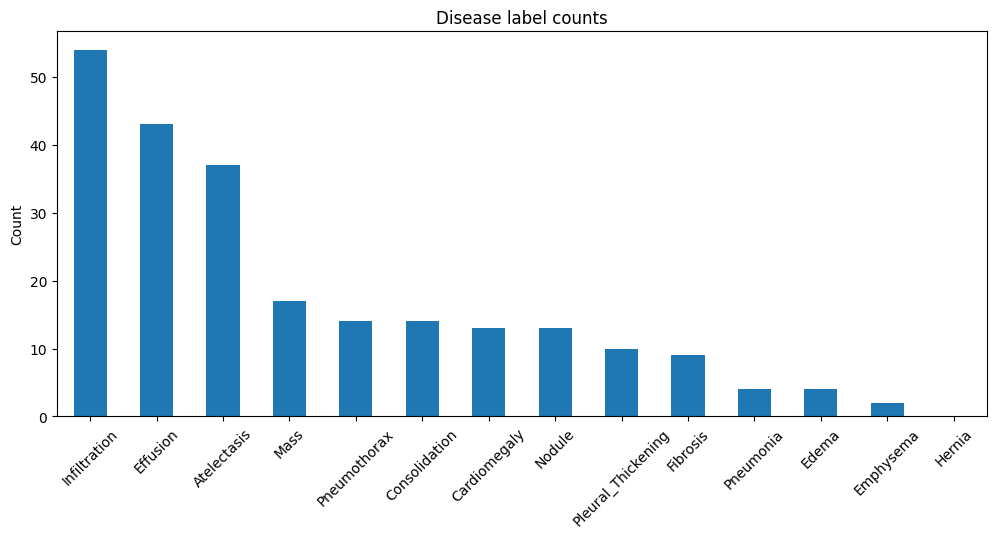

In [61]:
# Cell 7: Label distribution
label_counts = df[all_labels].sum().sort_values(ascending=False)
print(label_counts)

plt.figure(figsize=(12, 5))
label_counts.plot(kind="bar")
plt.title("Disease label counts")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [62]:
# Cell 8: Patient-level train/val split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, val_idx = next(splitter.split(df, groups=df["Patient ID"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

train_df = train_df[train_df["path"].map(os.path.exists)].reset_index(drop=True)
val_df   = val_df[val_df["path"].map(os.path.exists)].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Train patients:", train_df["Patient ID"].nunique())
print("Val patients  :", val_df["Patient ID"].nunique())

Train: (297, 18)
Val  : (55, 18)
Train patients: 273
Val patients  : 49


In [63]:
# Cell 9: Config
IMG_SIZE = 384
BATCH_SIZE = 16
EPOCHS = 50
BACKBONE_LR = 1e-5
HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4
# Jupyter: DataLoader workers cannot unpickle classes defined in the notebook (__main__).
# Use 0 here, or define NIHChestDataset in a .py module and set e.g. 2–4 workers.
NUM_WORKERS = 0
PATIENCE = 6
USE_AMP = torch.cuda.is_available()

In [64]:
# Cell 10: Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [65]:
# Cell 11: Dataset class
class NIHChestDataset(Dataset):
    def __init__(self, dataframe, labels, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["path"]).convert("L")
        image = np.array(image)
        image = np.stack([image, image, image], axis=-1)
        image = Image.fromarray(image)

        if self.transform is not None:
            image = self.transform(image)

        target = torch.tensor(row[self.labels].values.astype(np.float32))
        return image, target, row["path"]

In [66]:
# Cell 12: DataLoaders
train_dataset = NIHChestDataset(train_df, all_labels, transform=train_transform)
val_dataset   = NIHChestDataset(val_df, all_labels, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 19
Val batches  : 4


In [67]:
class ResNet50MultiLabel(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        
        weights = models.ResNet50_Weights.DEFAULT
        self.backbone = models.resnet50(weights=weights)

        in_features = self.backbone.fc.in_features

        # Replace classifier
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


model = ResNet50MultiLabel(num_classes=len(all_labels)).to(device)
print("ResNet50 Model ready")

ResNet50 Model ready


In [68]:
# Freeze all layers first
for param in model.backbone.parameters():
    param.requires_grad = False

# Unfreeze last layers (VERY IMPORTANT)
for param in model.backbone.layer3.parameters():
    param.requires_grad = True

for param in model.backbone.layer4.parameters():
    param.requires_grad = True

# Unfreeze classifier
for param in model.backbone.fc.parameters():
    param.requires_grad = True


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable params: {trainable:,}")
print(f"Total params    : {total:,}")

Trainable params: 22,091,790
Total params    : 23,536,718


In [69]:
# Cell 15: Weighted BCE loss
pos_counts = train_df[all_labels].sum().values.astype(np.float32)
neg_counts = (len(train_df) - pos_counts).astype(np.float32)

pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-6), dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW([
    {"params": model.backbone.layer3.parameters(), "lr": BACKBONE_LR},
    {"params": model.backbone.layer4.parameters(), "lr": BACKBONE_LR},
    {"params": model.backbone.fc.parameters(), "lr": HEAD_LR}
], weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=2
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

print("Loss, optimizer, scheduler ready")

Loss, optimizer, scheduler ready


In [70]:
# Cell 16: Metrics helpers
def compute_macro_auc(y_true, y_prob):
    aucs = []
    for i in range(y_true.shape[1]):
        if len(np.unique(y_true[:, i])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[:, i], y_prob[:, i]))
    return float(np.mean(aucs)) if len(aucs) > 0 else 0.0

def compute_per_class_auc(y_true, y_prob, labels):
    results = {}
    for i, label in enumerate(labels):
        if len(np.unique(y_true[:, i])) < 2:
            results[label] = None
        else:
            results[label] = roc_auc_score(y_true[:, i], y_prob[:, i])
    return results

In [71]:
# Cell 17: Training / validation functions
def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0

    pbar = tqdm(loader, total=len(loader))
    for images, targets, _ in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_targets = []
    all_probs = []

    pbar = tqdm(loader, total=len(loader))
    for images, targets, _ in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, targets)

        probs = torch.sigmoid(logits)

        running_loss += loss.item() * images.size(0)
        all_targets.append(targets.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    y_true = np.concatenate(all_targets, axis=0)
    y_prob = np.concatenate(all_probs, axis=0)

    val_loss = running_loss / len(loader.dataset)
    val_mauc = compute_macro_auc(y_true, y_prob)

    return val_loss, val_mauc, y_true, y_prob

In [72]:
# Cell 18: Train model with early stopping
best_auc = 0.0
best_epoch = 0
best_model_wts = copy.deepcopy(model.state_dict())
history = {"train_loss": [], "val_loss": [], "val_mauc": []}
patience_counter = 0

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_loss, val_mauc, y_true, y_prob = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step(val_mauc)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mauc"].append(val_mauc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss  : {val_loss:.4f}")
    print(f"Val mAUC  : {val_mauc:.4f}")

    if val_mauc > best_auc:
        best_auc = val_mauc
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_densenet_nih.pth")
        patience_counter = 0
        print("Best model saved")
    else:
        patience_counter += 1
        print(f"No improvement. Early-stop counter: {patience_counter}/{PATIENCE}")

    if patience_counter >= PATIENCE:
        print("Early stopping triggered")
        break

model.load_state_dict(best_model_wts)
print(f"\nBest Val mAUC: {best_auc:.4f} at epoch {best_epoch}")


Epoch 1/50


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 1.2832
Val Loss  : 1.2347
Val mAUC  : 0.4255
Best model saved

Epoch 2/50


  0%|          | 0/19 [00:00<?, ?it/s]

...

  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 1.1054
Val Loss  : 1.1721
Val mAUC  : 0.5458
No improvement. Early-stop counter: 5/6

Epoch 21/50


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

Train Loss: 1.0930
Val Loss  : 1.1753
Val mAUC  : 0.5416
No improvement. Early-stop counter: 6/6
Early stopping triggered

Best Val mAUC: 0.5550 at epoch 15


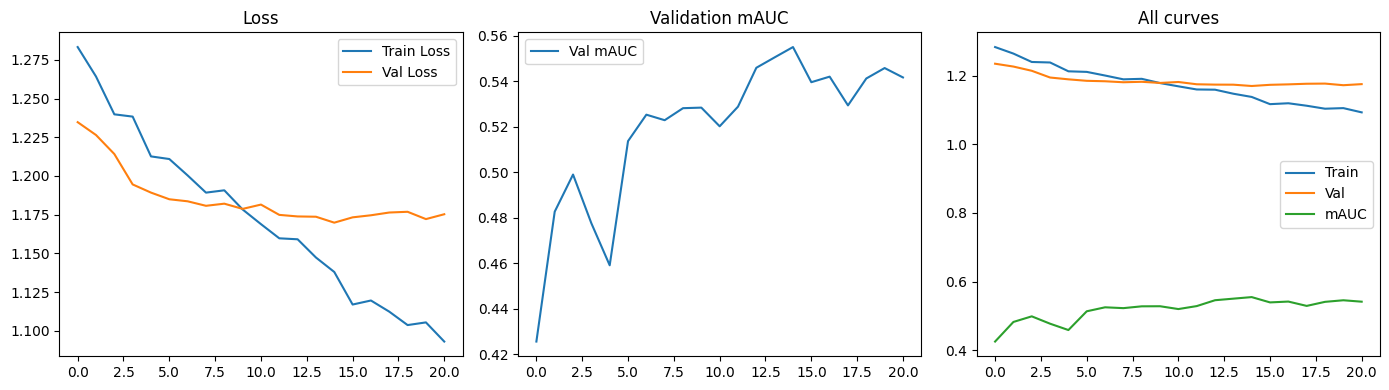

In [73]:
# Cell 19: Plot training history
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["val_mauc"], label="Val mAUC")
plt.title("Validation mAUC")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Val")
plt.plot(history["val_mauc"], label="mAUC")
plt.title("All curves")
plt.legend()

plt.tight_layout()
plt.show()

In [74]:
# Cell 20: Full evaluation + per-class AUC
val_loss, val_mauc, y_true, y_prob = validate_one_epoch(model, val_loader, criterion, device)
print(f"Final Val Loss : {val_loss:.4f}")
print(f"Final Val mAUC : {val_mauc:.4f}")

per_class_auc = compute_per_class_auc(y_true, y_prob, all_labels)
auc_table = pd.DataFrame({
    "Label": list(per_class_auc.keys()),
    "AUC": [per_class_auc[k] for k in per_class_auc.keys()]
}).sort_values(by="AUC", ascending=False, na_position="last")

display(auc_table)

  0%|          | 0/4 [00:00<?, ?it/s]

Final Val Loss : 1.1698
Final Val mAUC : 0.5550


,Label,AUC
2,Effusion,0.782313
8,Consolidation,0.750000
0,Atelectasis,0.692000
1,Cardiomegaly,0.666667
3,Infiltration,0.663265
11,Fibrosis,0.528302
7,Pneumothorax,0.496000
12,Pleural_Thickening,0.397436
5,Nodule,0.351852
4,Mass,0.222222


In [75]:
# Cell 21: Find best threshold for each class
best_thresholds = {}

for i, label in enumerate(all_labels):
    if len(np.unique(y_true[:, i])) < 2:
        best_thresholds[label] = 0.5
        continue

    best_t = 0.5
    best_f1 = -1

    for t in np.arange(0.1, 0.9, 0.05):
        pred = (y_prob[:, i] >= t).astype(int)
        score = f1_score(y_true[:, i], pred, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = float(t)

    best_thresholds[label] = best_t

threshold_df = pd.DataFrame({
    "Label": list(best_thresholds.keys()),
    "Best Threshold": list(best_thresholds.values())
})
display(threshold_df)

,Label,Best Threshold
0,Atelectasis,0.50
1,Cardiomegaly,0.45
2,Effusion,0.50
3,Infiltration,0.50
4,Mass,0.45
5,Nodule,0.45
6,Pneumonia,0.50
7,Pneumothorax,0.45
8,Consolidation,0.50
9,Edema,0.50


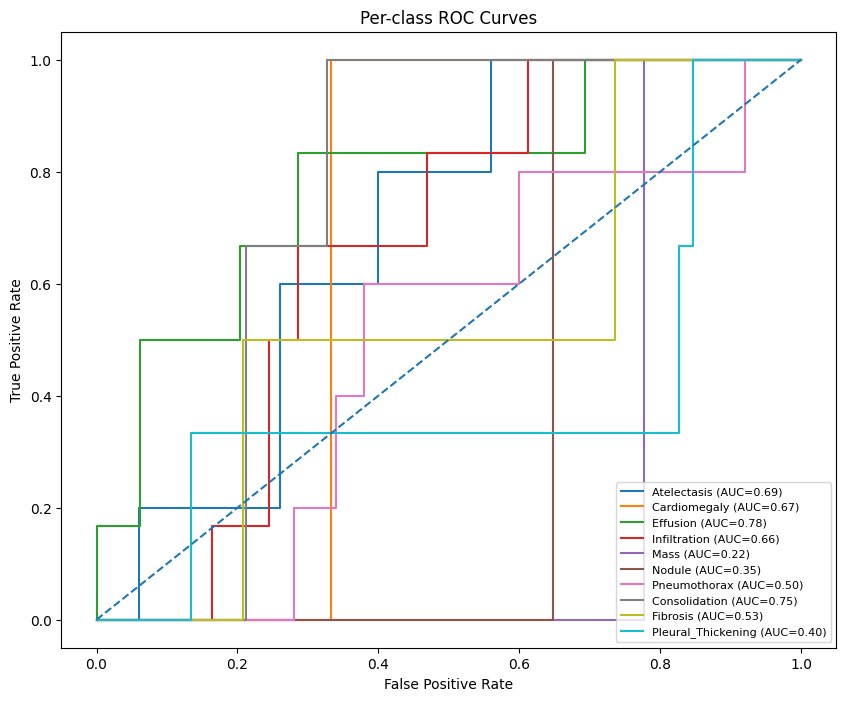

In [76]:
# Cell 22: ROC curves
plt.figure(figsize=(10, 8))
for i, label in enumerate(all_labels):
    if len(np.unique(y_true[:, i])) < 2:
        continue
    fpr, tpr, _ = roc_curve(y_true[:, i], y_prob[:, i])
    auc_val = roc_auc_score(y_true[:, i], y_prob[:, i])
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_val:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Per-class ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8, loc="lower right")
plt.show()

In [77]:
# Cell 23: Grad-CAM class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.fwd_hook = self.target_layer.register_forward_hook(self._save_activations)
        self.bwd_hook = self.target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inp, out):
        self.activations = out

    def _save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, target_class):
        self.model.zero_grad()
        logits = self.model(x)
        score = logits[:, target_class].sum()
        score.backward(retain_graph=True)

        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam = (weights * acts).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        cam = cam.squeeze().detach().cpu().numpy()

        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam

In [78]:
# Cell 24: BBox extraction from CAM
def extract_bbox_from_cam(cam, threshold=0.4):
    cam_uint8 = np.uint8(cam * 255)
    _, binary = cv2.threshold(cam_uint8, int(threshold * 255), 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return None

    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    return (x, y, x + w, y + h)

In [79]:
grad_cam = GradCAM(model, model.backbone.layer4)

def predict_with_bbox(model, image_path, target_label=None, cam_threshold=0.4):
    model.eval()

    raw_img = Image.open(image_path).convert("L")
    raw_img = raw_img.resize((IMG_SIZE, IMG_SIZE))
    raw_np = np.array(raw_img)
    rgb_np = np.stack([raw_np, raw_np, raw_np], axis=-1)

    pil_rgb = Image.fromarray(rgb_np)
    x = val_transform(pil_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()[0]

    if target_label is None:
        class_idx = int(np.argmax(probs))
    else:
        class_idx = all_labels.index(target_label)

    cam = grad_cam.generate(x, class_idx)
    bbox = extract_bbox_from_cam(cam, threshold=cam_threshold)

    pred_label = all_labels[class_idx]
    pred_prob = float(probs[class_idx])

    return rgb_np, cam, bbox, pred_label, pred_prob, probs

In [80]:
# Cell 26: Visualization
def show_prediction(image_path, target_label=None, cam_threshold=0.4):
    rgb_np, cam, bbox, pred_label, pred_prob, probs = predict_with_bbox(
        model, image_path, target_label=target_label, cam_threshold=cam_threshold
    )

    heatmap = np.uint8(255 * cam)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(rgb_np, 0.65, heatmap, 0.35, 0)

    if bbox is not None:
        x1, y1, x2, y2 = bbox
        cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_np, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap="jet")
    plt.title(f"Grad-CAM: {pred_label}\nProb={pred_prob:.3f}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title("Overlay + Bounding Box")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    top5_idx = np.argsort(probs)[::-1][:5]
    print("Top-5 predictions:")
    for idx in top5_idx:
        print(f"{all_labels[idx]:20s} : {probs[idx]:.4f}")

/Users/ahsanurrahman/Antigravity/NIH/small_nih_dataset/images/00009311_000.png


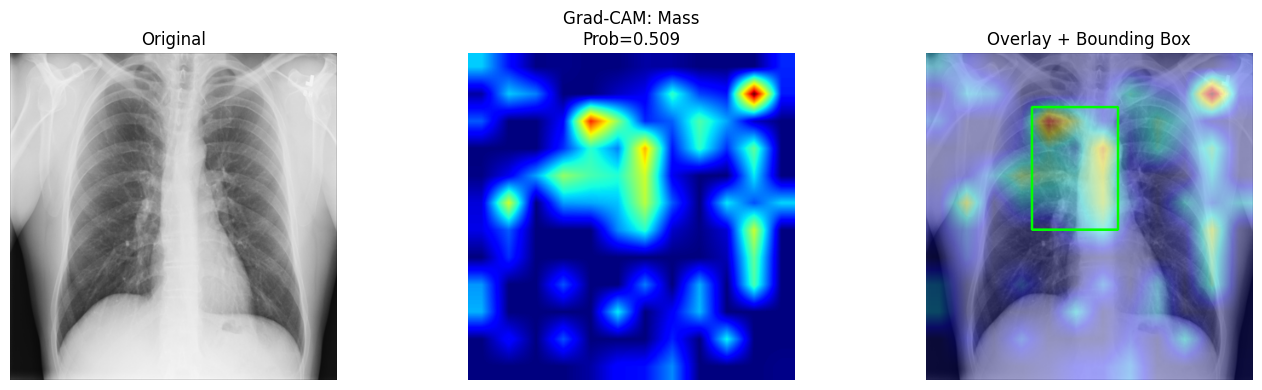

Top-5 predictions:
Mass                 : 0.5095
Pneumothorax         : 0.4979
Nodule               : 0.4942
Infiltration         : 0.4723
Cardiomegaly         : 0.4686


In [85]:
# Cell 27: Test on validation image
sample_path = val_df.iloc[4]["path"]
print(sample_path)
show_prediction(sample_path)